# Digital Signal Processing Training Program 

![Texto Alternativo](images/V-CC_Color_Completa_TextoAzul.png)

### Dev by:
-   Elmer Pimentel Farias


# *Sampling Rate Conversion*

 ###  1. Theoretical Introduction 

In modern Digital Signal Processing (DSP) applications, it is common to need different sampling rates to coexist within the same system. Multirate systems arise from the need to make these different rates compatible, and they perform this conversion fundamentally through two operations: decimation and interpolation.

- #### Decimation

    Downsampling by an integer factor $M$ consists of reducing the sampling rate of a discrete signal by keeping only one out of every $M$ original samples. Mathematically, the decimated signal $x_d[n]$ in the time domain is expressed as:$$x_d[n] = x[nM], \quad M \in \mathbb{Z}^+$$In the normalized frequency domain, decimation causes a spectral expansion, given by the relationship:$$X_d(\hat{f}) = \frac{1}{M}\sum_{q=0}^{M-1}X\left(\frac{\hat{f}-q}{M}\right)$$To avoid the phenomenon of aliasing (spectral overlap), decimation must be preceded by a low-pass filter (anti-aliasing) whose cutoff frequency $f_c$ obeys the criterion:$$f_c \le \frac{f_s}{2M}$$ 

- #### Interpolation

 Upsampling by a factor $L$ consists of increasing the sampling rate by inserting $L-1$ zeros between the samples of the original signal.The interpolated signal $x_i[n]$ is modeled as:$$x_i[n] = \begin{cases} x[n/L], & \text{if } n \text{ is a multiple of } L \\ 0, & \text{otherwise} \end{cases}$$This operation causes a spectral compression and the emergence of unwanted spectral copies (images) at multiples of $1/L$. Therefore, interpolation must be followed by a low-pass filter (anti-imaging) with a normalized cutoff frequency limiting the band to:$$\hat{f}_c \le \frac{1}{2L}$$

- ### To make these operations viable for long or real-time signals with computational efficiency, linear filtering is used operating in the frequency domain via the Fast Fourier Transform (FFT and IFFT), often combined with block processing algorithms, such as the overlap-and-save method.

 ### 2. Project Objectives:

 This practical report focuses on exploring and analyzing the behavior of multirate systems. The specific objectives include:
 - Implement linear filtering operations: Perform the decimation and interpolation of signals in the frequency domain, using algorithms based on FFT/IFFT combined with the overlap-and-save method for efficient processing.
 - Evaluate conversion distortions: Investigate and measure the distortions (such as aliasing and spectral imaging) introduced by the interpolation and decimation processes in previously band-limited signals.
 - Analyze spectral behavior: Observe, compare, and document the frequency spectrum of the signals before and after the interpolation and decimation operations, systematically varying the rate conversion factors ($M$ and $L$).

In [79]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import firwin
from fractions import Fraction


In [ ]:
def upsample_fft_ideal(x, L):
    """
    Performs spectral zero-padding by inserting zeros at high frequencies 
    to upsample the input signal.
    
    Args:
        x (array-like): The input signal in the time domain.
        L (int): The upsampling factor.
        
    Returns:
        numpy.ndarray: The upsampled time-domain signal.
    """
    # Step 1 & 2: Get the length of the input and calculate the new output length
    N_in = len(x)
    N_out = N_in * L
    
    # Step 3: Compute the Fast Fourier Transform (FFT) of the input signal
    X = np.fft.fft(x)
    
    # Step 4: Shift the zero-frequency (DC) component to the center of the spectrum
    X_c = np.fft.fftshift(X)
    
    # Step 5: Initialize a new zero-filled array for the expanded spectrum (ZeroVector)
    Y_c = np.zeros(N_out, dtype=complex)
    
    # Step 6: Place the original centered spectrum into the middle of the new zero-padded array.
    # This effectively pads the high-frequency components with zeros (ideal low-pass filtering).
    start = (N_out - N_in) // 2
    end = start + N_in
    Y_c[start:end] = X_c
    
    # Step 7: Inverse shift to move the DC component back to the edges
    Y = np.fft.ifftshift(Y_c)
    
    # Step 8: Compute the Inverse Fast Fourier Transform (IFFT) to return to the time domain.
    # np.real() ensures any residual imaginary parts from numerical imprecision are discarded.
    y = np.real(np.fft.ifft(Y))
    
    # Amplitude Compensation: Spreading the signal's energy across more bins 
    # reduces its time-domain amplitude. Multiplying by L restores the original amplitude.
    return y * L

In [84]:

def decimate_fft_ideal(x, M):
    """
    Performs ideal low-pass filtering by removing high-frequency bins 
    to downsample (decimate) the input signal.
    
    Args:
        x (array-like): The input signal in the time domain.
        M (int): The decimation factor.
        
    Returns:
        numpy.ndarray: The decimated time-domain signal.
    """
    # Step 1 & 2: Get the length of the input and calculate the new output length
    N_in = len(x)
    N_out = N_in // M 
    
    # Step 3: Compute the Fast Fourier Transform (FFT) of the input signal
    X = np.fft.fft(x)
    
    # Step 4: Shift the zero-frequency (DC) component to the center of the spectrum
    X_c = np.fft.fftshift(X)
    
    # Step 5: KeepCentralBins (Keep only the center of the spectrum)
    # This acts as an ideal low-pass filter, discarding high frequencies to avoid aliasing.
    start = (N_in - N_out) // 2
    end = start + N_out
    X_bb = X_c[start:end]
    
    # Step 6: Inverse shift to move the DC component back to the edges
    X_out = np.fft.ifftshift(X_bb)
    
    # Step 7: Compute the Inverse Fast Fourier Transform (IFFT) to return to the time domain
    y = np.real(np.fft.ifft(X_out))
    
    # Amplitude Compensation: The native IFFT function divides by the new length (N_out), 
    # but the original signal's spectral energy was based on N_in. 
    # We must compensate by dividing by the decimation factor M.
    return y / M

In [ ]:

def resample_fft_ideal(x, r):
    """
    Algorithm 1: resample_fft(x, r)
    """
    frac = Fraction(r).limit_denominator()
    L = frac.numerator
    M = frac.denominator
    
    print(f"[*] Fator r={r} -> L={L}, M={M} ")
    
    if L > 1:
        x_L = upsample_fft_ideal(x, L)
    else:
        x_L = x
        
    if M > 1:
        y = decimate_fft_ideal(x_L, M)
    else:
        y = x_L
        
    return y



[*] Fator r=1.5 -> L=3, M=2 (Modo: Corte FFT Ideal)


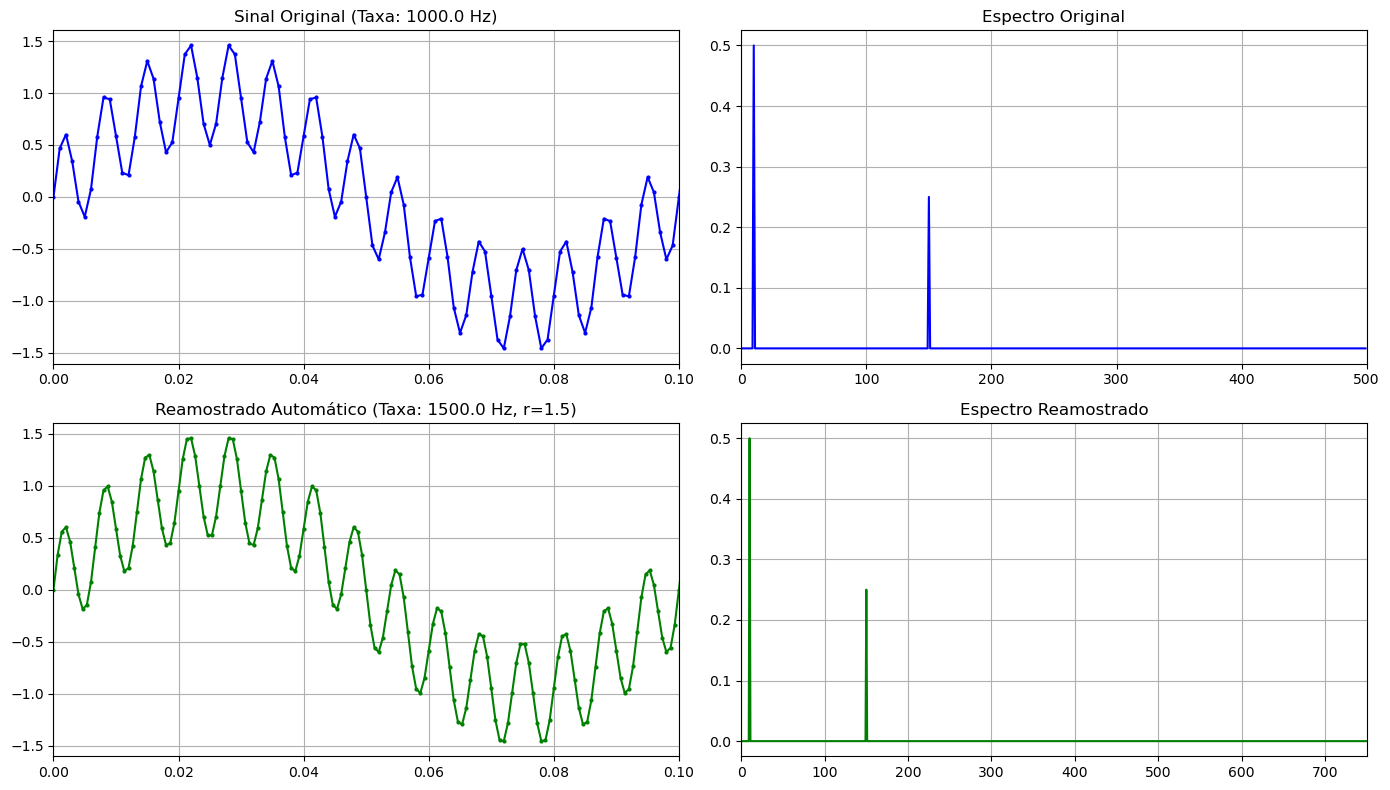

In [83]:
# Configuração Original
fs_orig = 1000.0
t_orig = np.arange(0, 1.0, 1/fs_orig)
# Sinal: 10 Hz + 150 Hz
x = np.sin(2 * np.pi * 10 * t_orig) + 0.5 * np.sin(2 * np.pi * 150 * t_orig)

# Aplicando a nova função (Processa o sinal inteiro de uma vez)
r_fator = 1.5
y_resampled = resample_fft_ideal(x, r=r_fator)

# Novo vetor de tempo
fs_new = fs_orig * r_fator
t_resampled = np.arange(0, len(y_resampled)) / fs_new

X_f = np.abs(np.fft.fft(x)) / len(x)
freqs_orig = np.fft.fftfreq(len(x), 1/fs_orig)
pos_idx_orig = freqs_orig >= 0

Y_f = np.abs(np.fft.fft(y_resampled)) / len(y_resampled)
freqs_new = np.fft.fftfreq(len(y_resampled), 1/fs_new)
pos_idx_new = freqs_new >= 0

fig, axs = plt.subplots(2, 2, figsize=(14, 8))

# Original no Tempo
axs[0, 0].plot(t_orig, x, 'b.-', markersize=4)
axs[0, 0].set_title(f'Sinal Original (Taxa: {fs_orig} Hz)')
axs[0, 0].set_xlim(0, 0.1)
axs[0, 0].grid(True)

# Original na Frequência
axs[0, 1].plot(freqs_orig[pos_idx_orig], X_f[pos_idx_orig], 'b')
axs[0, 1].set_title('Espectro Original')
axs[0, 1].set_xlim(0, fs_orig/2)
axs[0, 1].grid(True)

# Reamostrado no Tempo
axs[1, 0].plot(t_resampled, y_resampled, 'g.-', markersize=4)
axs[1, 0].set_title(f'Reamostrado Automático (Taxa: {fs_new} Hz, r={r_fator})')
axs[1, 0].set_xlim(0, 0.1)
axs[1, 0].grid(True)

# Reamostrado na Frequência
axs[1, 1].plot(freqs_new[pos_idx_new], Y_f[pos_idx_new], 'g')
axs[1, 1].set_title('Espectro Reamostrado')
axs[1, 1].set_xlim(0, fs_new/2)
axs[1, 1].grid(True)

plt.tight_layout()
plt.show()

#### Interpolação e Decimação no tempo

In [42]:


def decimate_diagram_ovs(x, h, M, N_fft):
    """
    Decimação via FFT manipulando o espectro no domínio da frequência
    conforme o diagrama do quadro branco.
    """
    P = len(h)
    
    # Para o OVS casar perfeitamente com a redução da IFFT,
    # o overlap (P-1) deve ser múltiplo de M. 
    # Caso não seja, fazemos um leve padding no filtro.
    if (P - 1) % M != 0:
        pad_len = M - ((P - 1) % M)
        h = np.pad(h, (0, pad_len), mode='constant')
        P = len(h)
        
    step = N_fft - P + 1
    
    # FFT do filtro (Tamanho N_fft)
    H = np.fft.fft(h, N_fft)
    
    # Preenchimento inicial para o Overlap-and-Save
    pad_end = N_fft - (len(x) % step)
    x_padded = np.pad(x, (P - 1, pad_end), mode='constant')
    
    y_out = []
    
    for i in range(0, len(x_padded) - N_fft + 1, step):
        x_block = x_padded[i : i + N_fft]
        
        # 1. FFT
        X_f = np.fft.fft(x_block)
        
        # 2. Multiplicação pelo Filtro Antialiasing H(f)
        Y_f = X_f * H
        
        # 3. DownSampling Fator M na Frequência (Aliasing/Averaging)
        # Transforma o vetor de N_fft para N_fft // M
        Y_d = np.mean(Y_f.reshape(M, N_fft // M), axis=0)
        
        # 4. IFFT (agora mais rápida, tamanho reduzido)
        y_block = np.real(np.fft.ifft(Y_d))
        
        # Descarte do Lixo Circular (Overlap reduzido por M)
        discard_len = (P - 1) // M
        y_valid = y_block[discard_len:]
        
        y_out.extend(y_valid)
        
    expected_len = int(np.ceil(len(x) / M))
    return np.array(y_out)[:expected_len]




In [43]:
def interpolate_diagram_ovs(x, h, L, N_fft_in):
    """
    Interpolação via FFT replicando o espectro (UpSampling) 
    antes da IFFT, conforme diagrama do quadro.
    """
    P = len(h) # Tamanho do filtro na taxa ALTA
    N_fft_out = N_fft_in * L
    
    # O passo e o overlap de entrada ocorrem na taxa BAIXA
    overlap_in = int(np.ceil((P - 1) / L))
    step_in = N_fft_in - overlap_in
    
    # FFT do filtro na taxa expandida (ganho compensado por L)
    H = np.fft.fft(h * L, N_fft_out)
    
    pad_end = N_fft_in - (len(x) % step_in)
    x_padded = np.pad(x, (overlap_in, pad_end), mode='constant')
    
    y_out = []
    
    for i in range(0, len(x_padded) - N_fft_in + 1, step_in):
        x_block = x_padded[i : i + N_fft_in]
        
        # 1. FFT (Tamanho reduzido N_fft_in)
        X_f = np.fft.fft(x_block)
        
        # 2. UpSampling Fator L na Frequência (Replicação do Espectro)
        X_up_f = np.tile(X_f, L)
        
        # 3. Multiplicação pelo Filtro Anti-imagem H(f)
        Y_f = X_up_f * H
        
        # 4. IFFT (Tamanho expandido N_fft_out)
        y_block = np.real(np.fft.ifft(Y_f))
        
        # Descarte do Lixo Circular na taxa alta
        discard_len = overlap_in * L
        valid_len = step_in * L
        y_valid = y_block[discard_len : discard_len + valid_len]
        
        y_out.extend(y_valid)
        
    expected_len = len(x) * L
    return np.array(y_out)[:expected_len]

In [44]:

def resample_fft(x, r, P=65, N_fft_in=256, N_fft_out=256):
    """
    Reamostra um sinal por um fator racional r = L/M calculando
    automaticamente os filtros ideais para a conversão.
    
    Parâmetros:
    x         : Sinal de entrada
    r         : Razão de reamostragem (L/M)
    P         : Tamanho (número de coeficientes) dos filtros FIR (padrão=65)
    N_fft_in  : Tamanho do bloco da FFT para a interpolação
    N_fft_out : Tamanho do bloco da FFT para a decimação
    """
    frac = Fraction(r).limit_denominator()
    L = frac.numerator
    M = frac.denominator
    
    # 1. Etapa de Interpolação (se L > 1)
    if L > 1:
        # Projeto do filtro Anti-imagem: fc = 1 / 2L
        cutoff_up = 1.0 / (2 * L)
        h_up = firwin(P, cutoff_up, fs=1.0)
        
        x_L = interpolate_diagram_ovs(x, h_up, L, N_fft_in)
    else:
        x_L = x
        
    # 2. Etapa de Decimação (se M > 1)
    if M > 1:
        # Projeto do filtro Antialiasing: fc = 1 / 2M
        cutoff_down = 1.0 / (2 * M)
        h_down = firwin(P, cutoff_down, fs=1.0)
        
        y = decimate_diagram_ovs(x_L, h_down, M, N_fft_out)
    else:
        y = x_L
        
    return y

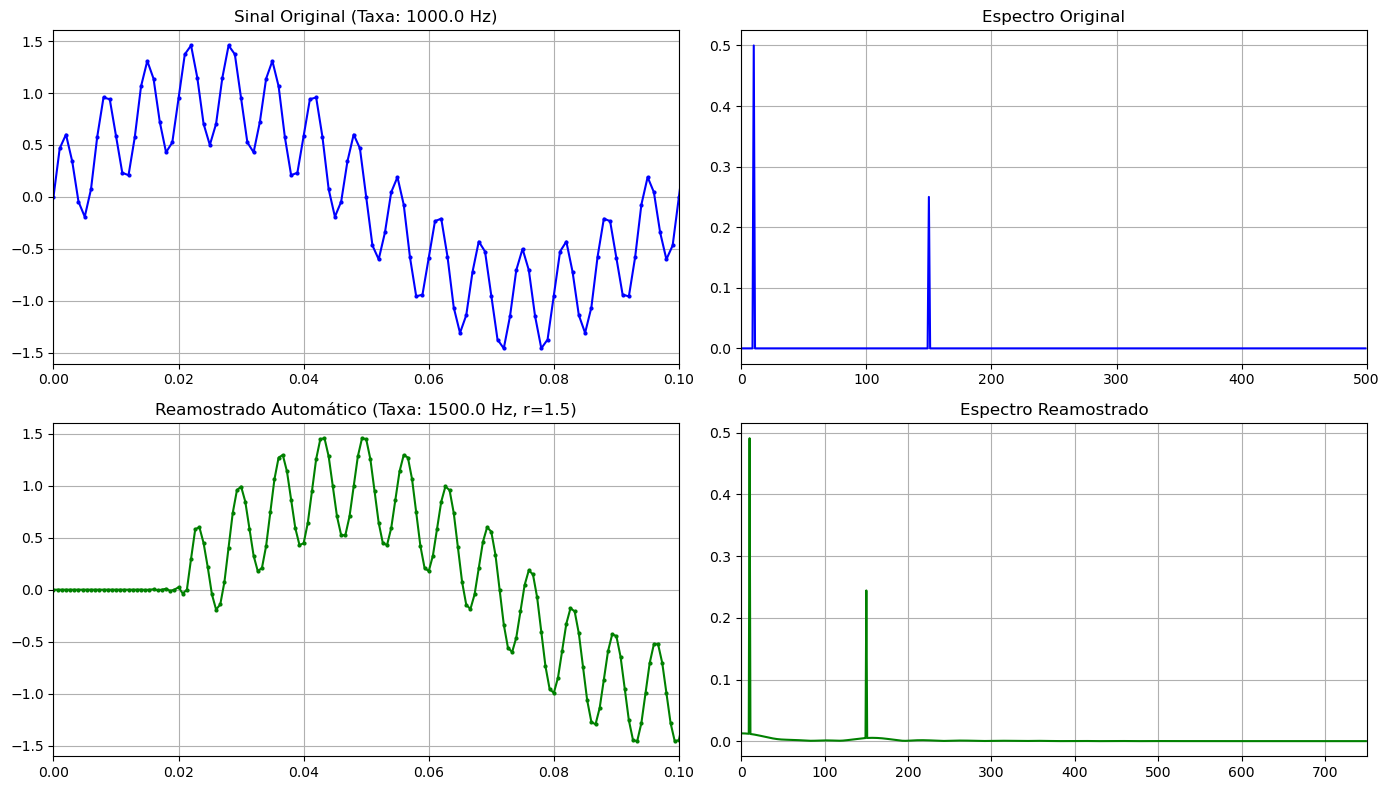

In [74]:
fs_orig = 1000.0
t_orig = np.arange(0, 1.0, 1/fs_orig)
x = np.sin(2 * np.pi * 10 * t_orig) + 0.5 * np.sin(2 * np.pi * 150 * t_orig)

# Aplicando a sua função! Tudo acontece aqui, de forma transparente.
r_fator = 1.5
y_resampled = resample_fft(x, r=r_fator, P=65, N_fft_in=128, N_fft_out=384)

# Gerando eixos de tempo e frequência para o novo sinal
fs_new = fs_orig * r_fator
t_resampled = np.arange(0, len(y_resampled)) / fs_new

# ==========================================
# 4. Geração dos Gráficos (Matriz 2x2)
# ==========================================
# Espectros
X_f = np.abs(np.fft.fft(x)) / len(x)
freqs_orig = np.fft.fftfreq(len(x), 1/fs_orig)
pos_idx_orig = freqs_orig >= 0

Y_f = np.abs(np.fft.fft(y_resampled)) / len(y_resampled)
freqs_new = np.fft.fftfreq(len(y_resampled), 1/fs_new)
pos_idx_new = freqs_new >= 0

fig, axs = plt.subplots(2, 2, figsize=(14, 8))

# Original no Tempo
axs[0, 0].plot(t_orig, x, 'b.-', markersize=4)
axs[0, 0].set_title(f'Sinal Original (Taxa: {fs_orig} Hz)')
axs[0, 0].set_xlim(0, 0.1)
axs[0, 0].grid(True)

# Original na Frequência
axs[0, 1].plot(freqs_orig[pos_idx_orig], X_f[pos_idx_orig], 'b')
axs[0, 1].set_title('Espectro Original')
axs[0, 1].set_xlim(0, fs_orig/2)
axs[0, 1].grid(True)

# Reamostrado no Tempo
axs[1, 0].plot(t_resampled, y_resampled, 'g.-', markersize=4)
axs[1, 0].set_title(f'Reamostrado Automático (Taxa: {fs_new} Hz, r={r_fator})')
axs[1, 0].set_xlim(0, 0.1)
axs[1, 0].grid(True)

# Reamostrado na Frequência
axs[1, 1].plot(freqs_new[pos_idx_new], Y_f[pos_idx_new], 'g')
axs[1, 1].set_title('Espectro Reamostrado')
axs[1, 1].set_xlim(0, fs_new/2)
axs[1, 1].grid(True)

plt.tight_layout()
plt.show()

[*] Fator r=1.5 -> L=3, M=2 (Modo: Corte FFT Ideal)


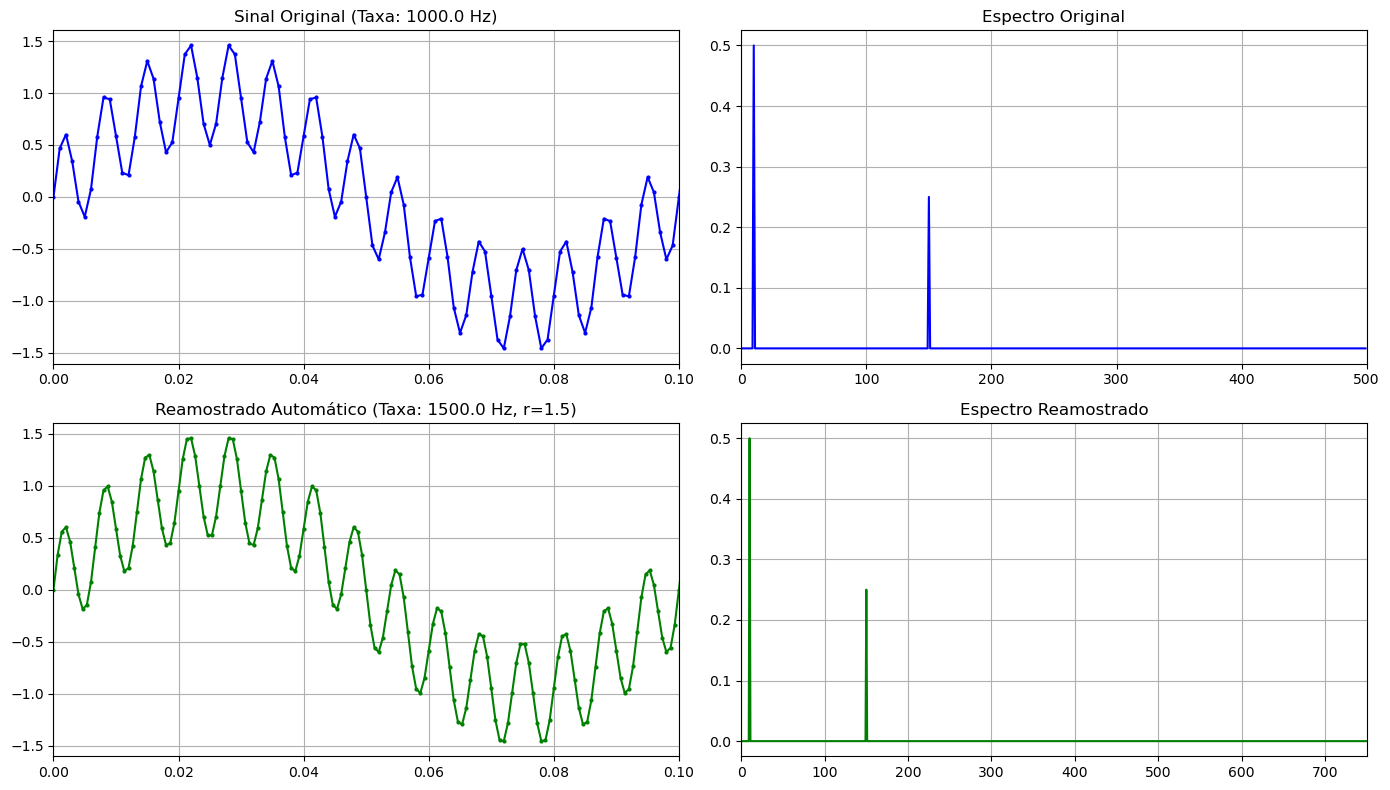

----

In [22]:

def decimate_overlap_save(x, h, M, N_fft):
    """
    Filtra e decima um sinal usando Overlap-and-Save.
    
    Parâmetros:
    x     : Sinal de entrada (1D array)
    h     : Resposta ao impulso do filtro passa-baixas antialiasing (1D array)
    M     : Fator de decimação (inteiro)
    N_fft : Tamanho da FFT (deve ser >= len(h))
    """
    P = len(h)
    if N_fft < P:
        raise ValueError("O tamanho da FFT deve ser maior ou igual ao tamanho do filtro.")
        
    step = N_fft - P + 1 # Tamanho do salto (bloco de amostras novas)
    
    # 1. FFT do filtro (calculada apenas uma vez)
    H = np.fft.fft(h, N_fft)
    
    # 2. Preenchimento (padding) inicial com P-1 zeros no sinal de entrada
    x_padded = np.pad(x, (P - 1, 0), mode='constant')
    
    y_out = []
    global_valid_idx = 0 # Rastreador do índice global para manter a subamostragem correta
    
    # 3. Processamento por blocos
    for i in range(0, len(x_padded) - N_fft + 1, step):
        # Extrai o bloco atual
        x_block = x_padded[i : i + N_fft]
        
        # Convolução rápida via FFT/IFFT
        X_block = np.fft.fft(x_block)
        Y_block = X_block * H
        y_block = np.real(np.fft.ifft(Y_block))
        
        # Descarta as primeiras P-1 amostras (lixo da convolução circular)
        y_valid = y_block[P - 1:]
        
        # 4. Decimação do bloco válido
        # Precisamos garantir que estamos pegando as amostras corretas considerando a continuidade
        start_idx = (M - (global_valid_idx % M)) % M
        y_decimated = y_valid[start_idx :: M]
        
        y_out.extend(y_decimated)
        global_valid_idx += len(y_valid)
        
    return np.array(y_out)


def interpolate_overlap_save(x, h, L, N_fft):
    """
    Interpola e filtra um sinal usando Overlap-and-Save.
    
    Parâmetros:
    x     : Sinal de entrada (1D array)
    h     : Resposta ao impulso do filtro passa-baixas anti-imagem (1D array)
    L     : Fator de interpolação (inteiro)
    N_fft : Tamanho da FFT (deve ser >= len(h))
    """
    P = len(h)
    if N_fft < P:
        raise ValueError("O tamanho da FFT deve ser maior ou igual ao tamanho do filtro.")
        
    # 1. Sobreamostragem: Inserir L-1 zeros entre as amostras
    x_up = np.zeros(len(x) * L)
    x_up[::L] = x
    
    step = N_fft - P + 1
    
    # 2. FFT do filtro (multiplicado por L para compensar a perda de energia dos zeros)
    H = np.fft.fft(h * L, N_fft)
    
    # 3. Preenchimento inicial com P-1 zeros
    x_padded = np.pad(x_up, (P - 1, 0), mode='constant')
    
    y_out = []
    
    # 4. Processamento por blocos sobre o sinal já expandido
    for i in range(0, len(x_padded) - N_fft + 1, step):
        x_block = x_padded[i : i + N_fft]
        
        # Convolução rápida via FFT/IFFT
        X_block = np.fft.fft(x_block)
        Y_block = X_block * H
        y_block = np.real(np.fft.ifft(Y_block))
        
        # Descarta as primeiras P-1 amostras
        y_valid = y_block[P - 1:]
        y_out.extend(y_valid)
        
    return np.array(y_out)

In [23]:
def decimate_overlap_save(x, h, M, N_fft):
    P = len(h)
    step = N_fft - P + 1
    H = np.fft.fft(h, N_fft)
    
    # CALCULANDO O PADDING FINAL: Garante que a "cauda" do sinal caiba no último bloco
    pad_end = N_fft - (len(x) % step) 
    x_padded = np.pad(x, (P - 1, pad_end), mode='constant')
    
    y_out = []
    global_valid_idx = 0
    
    for i in range(0, len(x_padded) - N_fft + 1, step):
        x_block = x_padded[i : i + N_fft]
        y_block = np.real(np.fft.ifft(np.fft.fft(x_block) * H))
        y_valid = y_block[P - 1:]
        
        start_idx = (M - (global_valid_idx % M)) % M
        y_decimated = y_valid[start_idx :: M]
        y_out.extend(y_decimated)
        global_valid_idx += len(y_valid)
        
    # Trunca o excesso para o tamanho exato de uma decimação
    expected_len = int(np.ceil(len(x) / M))
    return np.array(y_out)[:expected_len]

def interpolate_overlap_save(x, h, L, N_fft):
    P = len(h)
    x_up = np.zeros(len(x) * L)
    x_up[::L] = x
    step = N_fft - P + 1
    H = np.fft.fft(h * L, N_fft) 
    
    # CALCULANDO O PADDING FINAL
    pad_end = N_fft - (len(x_up) % step)
    x_padded = np.pad(x_up, (P - 1, pad_end), mode='constant')
    
    y_out = []
    
    for i in range(0, len(x_padded) - N_fft + 1, step):
        x_block = x_padded[i : i + N_fft]
        y_block = np.real(np.fft.ifft(np.fft.fft(x_block) * H))
        y_valid = y_block[P - 1:]
        y_out.extend(y_valid)
        
    # Trunca o excesso para o tamanho exato de uma interpolação
    expected_len = len(x) * L
    return np.array(y_out)[:expected_len]

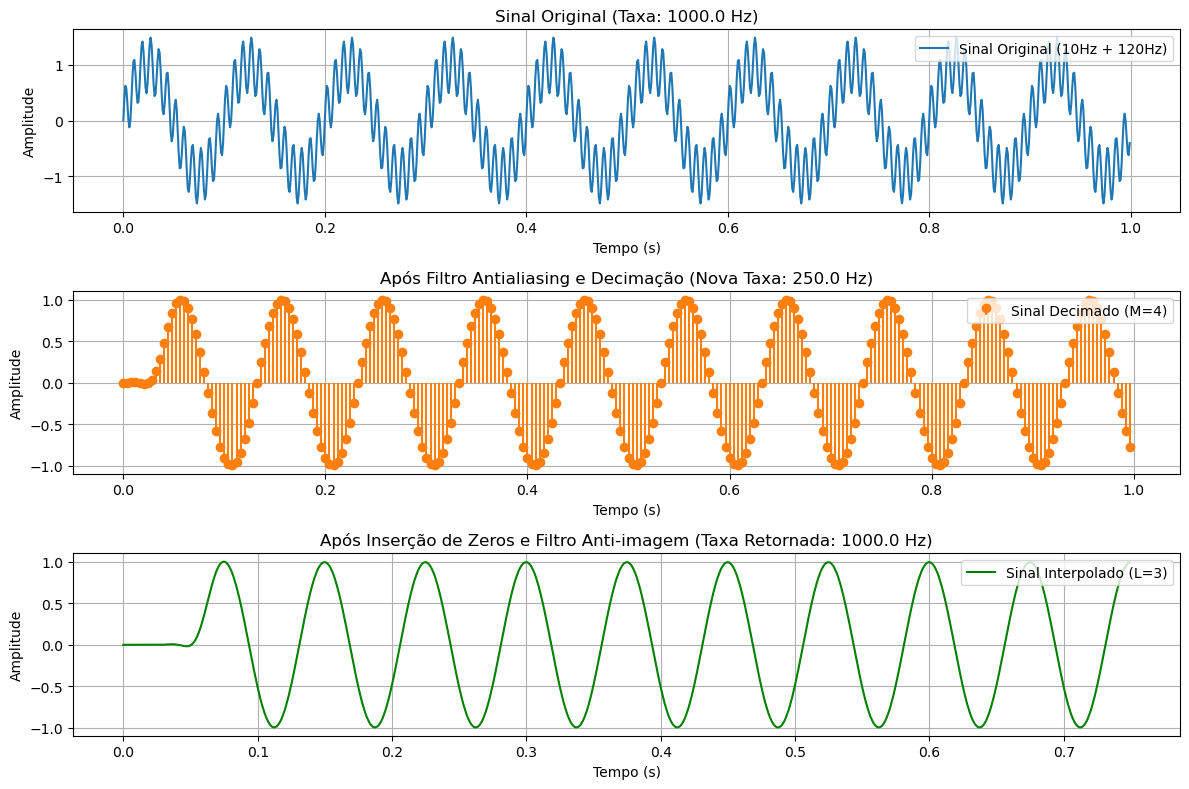

In [24]:
fs = 1000.0          # Frequência de amostragem original (Hz)
t = np.arange(0, 1.0, 1/fs) # 1 segundo de sinal

# Sinal: 10 Hz (desejado) + 120 Hz (ruído/alta frequência)
x = np.sin(2 * np.pi * 10 * t) + 0.5 * np.sin(2 * np.pi * 120 * t)

# Parâmetros de Multitaxa
M = 4 # Fator de decimação
L = 3 # Fator de interpolação
N_fft = 256 # Tamanho da FFT (Bloco)

# Projeto do Filtro FIR Passa-Baixas (Comprimento P = 65)
# Frequência de Nyquist = fs/2 = 500 Hz. Corte em 50 Hz para eliminar os 120 Hz.
cutoff_hz = 50.0
h_fir = firwin(65, cutoff_hz, fs=fs)

# ==========================================
# 3. Execução do Processamento
# ==========================================
# A) Decimação
y_decimado = decimate_overlap_save(x, h_fir, M, N_fft)
t_decimado = np.arange(0, len(y_decimado)) * (M / fs)

# B) Interpolação (reconstruindo o sinal decimado)
y_interpolado = interpolate_overlap_save(y_decimado, h_fir, L, N_fft)
# Ajuste de tamanho para o plot (O OLA pode gerar algumas amostras a mais no final do último bloco)
y_interpolado = y_interpolado[:len(x)] 
# Trunca o vetor de tempo para ter o mesmo tamanho do sinal interpolado
t_interpolado = t[:len(y_interpolado)]
# ==========================================
# 4. Visualização
# ==========================================
plt.figure(figsize=(12, 8))

# Sinal Original
plt.subplot(3, 1, 1)
plt.plot(t, x, label='Sinal Original (10Hz + 120Hz)')
plt.title(f'Sinal Original (Taxa: {fs} Hz)')
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude')
plt.grid(True); plt.legend(loc='upper right')

# Sinal Decimado
plt.subplot(3, 1, 2)
plt.stem(t_decimado, y_decimado, basefmt=" ", linefmt='C1-', markerfmt='C1o', label=f'Sinal Decimado (M={M})')
plt.title(f'Após Filtro Antialiasing e Decimação (Nova Taxa: {fs/M} Hz)')
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude')
plt.grid(True); plt.legend(loc='upper right')

# Sinal Interpolado
plt.subplot(3, 1, 3)
plt.plot(t_interpolado, y_interpolado, color='green', label=f'Sinal Interpolado (L={L})')
plt.title(f'Após Inserção de Zeros e Filtro Anti-imagem (Taxa Retornada: {fs} Hz)')
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude')
plt.grid(True); plt.legend(loc='upper right')

plt.tight_layout()
plt.show()